In [1]:
import numpy as np
from OptimalBattery.util import build_combinations
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.ticker as ticker
from OptimalBattery.plot import plot_correlations
from IndividualParcellation.global_config import *
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
import PcmPy as pcm
import os
import seaborn as sns

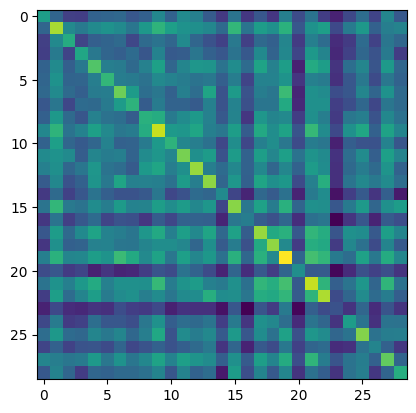

In [2]:
# Make G library random G 
Z = np.random.rand(29, 29)
GL = Z @ Z.T
plt.imshow(GL)

In [3]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D = build_combinations(G_lib=GL,strategy='random',n_iter=1000,offs = offsets, n_tasks=8,seed=3)

building0


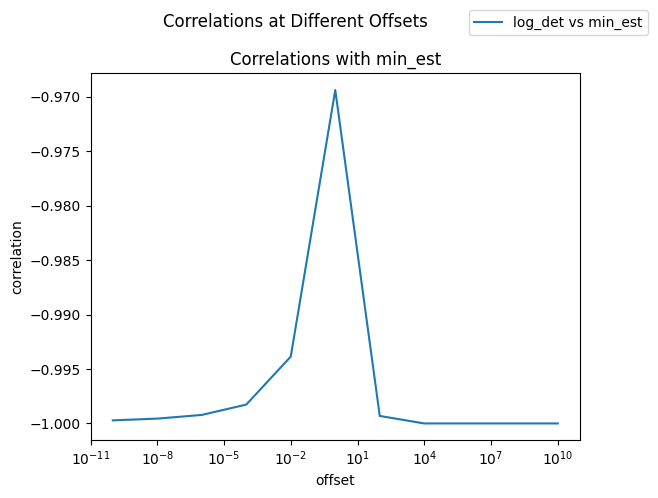

In [4]:
plot_correlations(D = D, x_vars= ['log_det'],y_vars = ['min_est'])

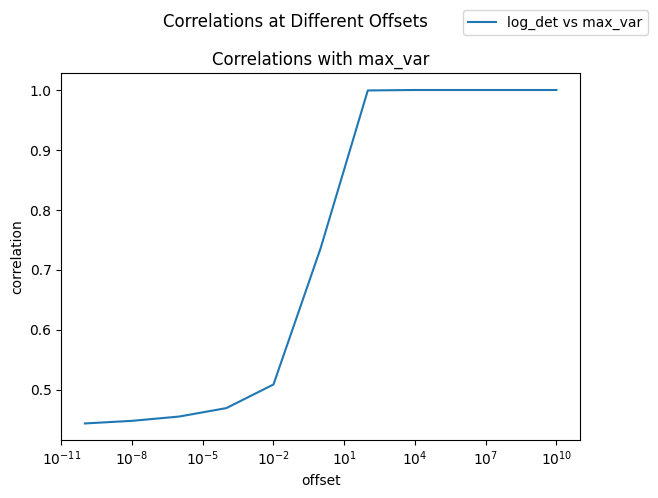

In [5]:
plot_correlations(D = D, x_vars= ['log_det'],y_vars = ['max_var'])

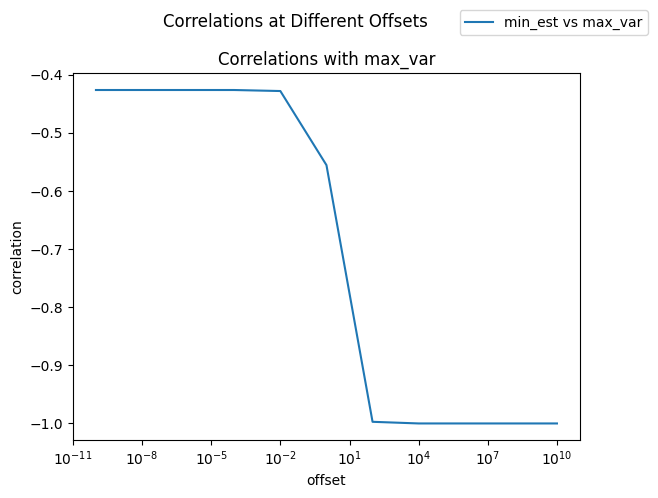

In [6]:
plot_correlations(D = D, x_vars= ['min_est'],y_vars = ['max_var'])

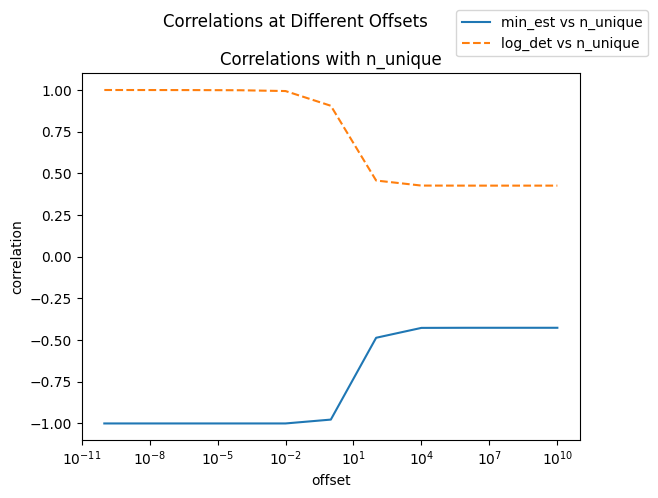

In [7]:
plot_correlations(D = D, x_vars= ['min_est','log_det'],y_vars = ['n_unique'])

In [8]:
# print correaltion between max_var and n_unique at all offsets
for offset in D['offset'].unique():
    print(offset)
    print(pearsonr(D[D['offset'] == offset]['max_var'],D[D['offset'] == offset]['n_unique']))

1e-10
PearsonRResult(statistic=0.42624454614513, pvalue=2.080479795898696e-45)
1e-08
PearsonRResult(statistic=0.4262445461451299, pvalue=2.0804797958990297e-45)
1e-06
PearsonRResult(statistic=0.4262445461451298, pvalue=2.0804797958990297e-45)
0.0001
PearsonRResult(statistic=0.42624454614513047, pvalue=2.080479795898255e-45)
0.01
PearsonRResult(statistic=0.4262445461451297, pvalue=2.0804797958993508e-45)
1.0
PearsonRResult(statistic=0.42624454614513013, pvalue=2.080479795898696e-45)
100.0
PearsonRResult(statistic=0.4262445461451289, pvalue=2.0804797958999345e-45)
10000.0
PearsonRResult(statistic=0.42624454614513135, pvalue=2.08047979589747e-45)
1000000.0
PearsonRResult(statistic=0.426244546146664, pvalue=2.0804797942327433e-45)
100000000.0
PearsonRResult(statistic=0.4262445460851702, pvalue=2.080479861035752e-45)
10000000000.0
PearsonRResult(statistic=0.42624449318620733, pvalue=2.080537328200149e-45)


# mdtb covariance

<Axes: >

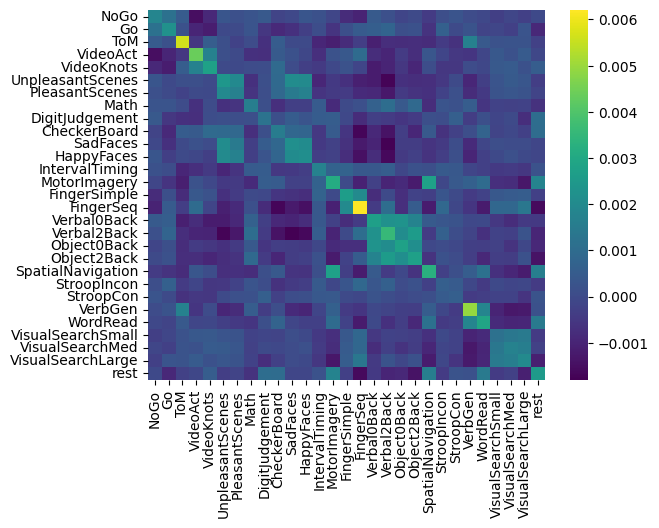

In [9]:


base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
if not os.path.exists(base_dir):
    base_dir = 'Y:/data/FunctionalFusion'
space = 'SUIT3'
atlas, _ = am.get_atlas(space)


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondAll')
task_names = info_mdtb_1.cond_name.values


MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

task_matrix = data_mdtb_s1 
task_matrix[np.isnan(task_matrix)] = 0

cond_vec = np.tile(np.arange(1, 29 + 1), 16)
part_vec = np.repeat(np.arange(1, 16 + 1), 29)

Gs_list = []
E_list = []
for i in range(task_matrix.shape[0]):
    Gs,E = pcm.util.est_G_crossval(task_matrix[i], cond_vec, part_vec)
    Gs_list.append(Gs)
    E_list.append(E)

Gs_list = np.stack(Gs_list, 0)
G_individuals_averaged = np.mean(Gs_list, axis=0)

sns.heatmap(G_individuals_averaged, cmap='viridis', xticklabels=task_names, yticklabels=task_names)

In [10]:
D_mdtv = build_combinations(G_lib=G_individuals_averaged,strategy='random',n_iter=10000,offs = offsets, n_tasks=8,seed=1)

building0


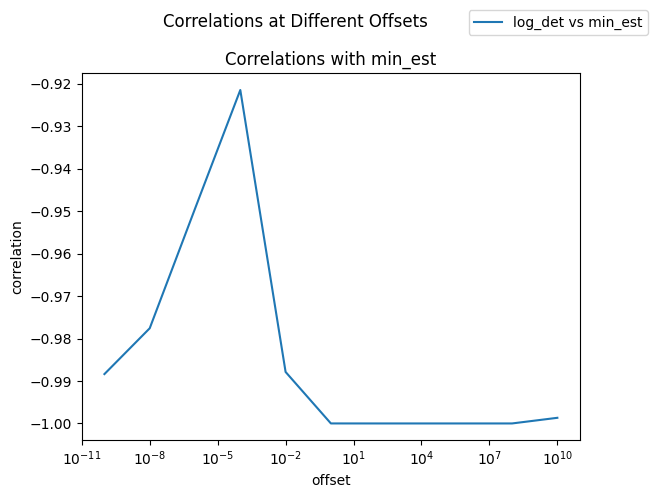

In [11]:
plot_correlations(D_mdtv,x_vars=['log_det'],y_vars=['min_est'])


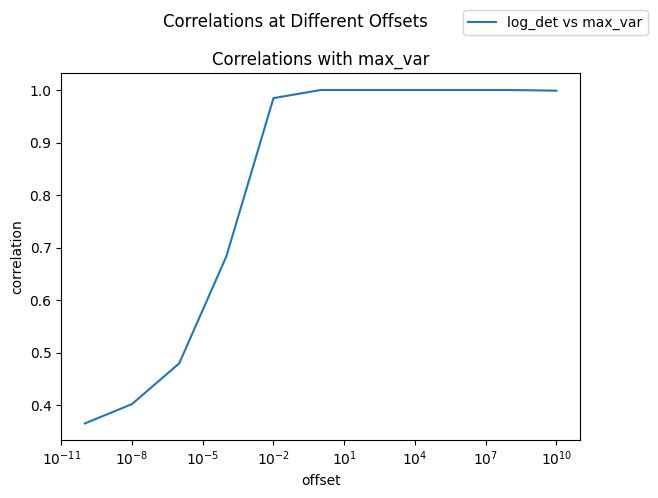

In [12]:
plot_correlations(D = D_mdtv, x_vars= ['log_det'],y_vars = ['max_var'])

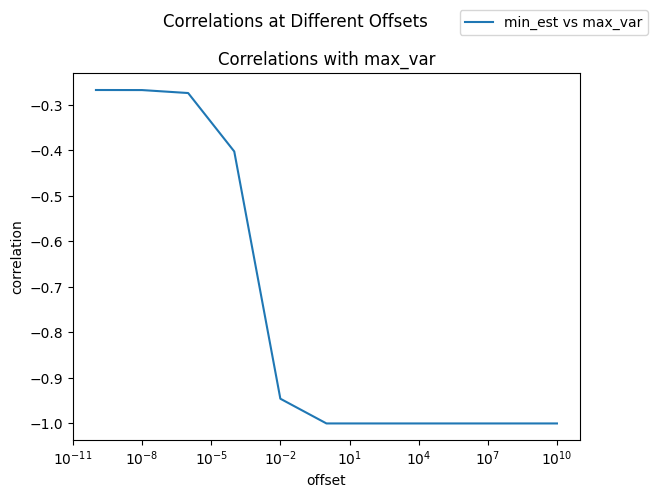

In [13]:
plot_correlations(D = D_mdtv, x_vars= ['min_est'],y_vars = ['max_var'])

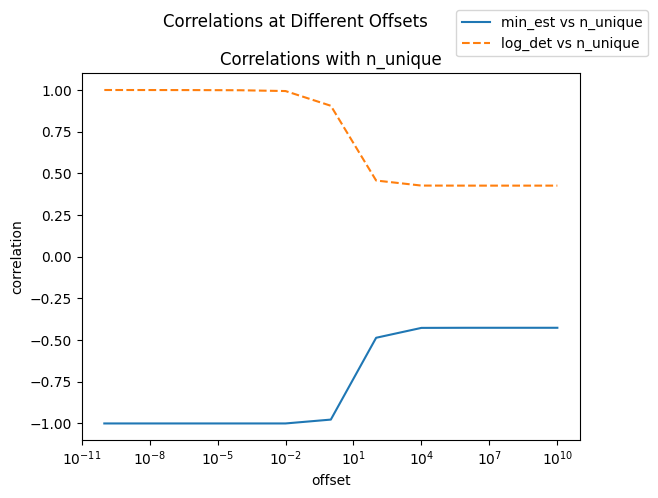

In [14]:
plot_correlations(D = D, x_vars= ['min_est','log_det'],y_vars = ['n_unique'])

# looks like log_det cares about variance more than min_est, simulate scaneraio where they disagree

In [15]:

Matrix_A = np.array([
    [5.0, 4.5, 4.5],
    [4.5, 5.0, 4.5],
    [4.5, 4.5, 5.0]
])

Matrix_B = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 1.5, 0.0],
    [0.0, 0.0, 2.0]
])


In [16]:
eigvals_A = np.linalg.eigvalsh(Matrix_A)
eigvals_B = np.linalg.eigvalsh(Matrix_B)

offset = 0.1
lex_A = eigvals_A + offset
lex_B = eigvals_B + offset

# Compute min_est (sum of inverses of eigenvalues)
min_est_A = np.sum(1 / lex_A)
min_est_B = np.sum(1 / lex_B)

# Compute log_det (sum of logs of eigenvalues)
log_det_A = np.sum(np.log(lex_A))
log_det_B = np.sum(np.log(lex_B))

print("\nMatrix A:")
print("eigvals:", eigvals_A)
print("  min_est:", min_est_A)
print("  log_det:", log_det_A)

print("\nMatrix B:")
print("eigvals:", eigvals_B)
print("  min_est:", min_est_B)
print("  log_det:", log_det_B)



Matrix A:
eigvals: [ 0.5  0.5 14. ]
  min_est: 3.404255319148935
  log_det: 1.6245235498521424

Matrix B:
eigvals: [1.  1.5 2. ]
  min_est: 2.0102813852813854
  log_det: 1.307251153779438


# quantify how much each metric cares about variance at different reguulariaxation factors

In [17]:
def compute_log_det(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    log_det = np.sum(np.log(eigenvalues))
    return log_det

def compute_min_est(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    eigenvalues = np.linalg.eigvalsh(cov_matrix_reg)
    min_est = np.sum(1 / eigenvalues)
    return min_est
def compute_max_var(cov_matrix, offset):
    cov_matrix_reg = cov_matrix + np.eye(cov_matrix.shape[0]) * offset
    max_var = np.sum(np.diag(cov_matrix_reg))
    return max_var

In [40]:
# Define ranges for variance and correlation
variance_values = np.linspace(1, 10, 20)
correlation_values = np.linspace(0, 0.99, 20)

# Define different offsets to test
offset_values = [1e-8, 1e-6, 1e-4, 1e-2, 1, 1e2, 1e4, 1e6, 1e8]
n_tasks = 4

In [41]:
from sklearn.linear_model import LinearRegression

offsets = []
perc_var_log_dets = []
perc_corr_log_dets = []
perc_var_min_ests = []
perc_corr_min_ests = []
perc_var_max_vars = []
perc_corr_max_vars = []

for offset in offset_values:
    variance_list = []
    correlation_list = []
    log_det_values = []
    min_est_values = []
    max_var_values = []

    for variance in variance_values:
        for correlation in correlation_values:
            covariance = correlation * variance

            # Create covariance matrix (3x3 for simplicity)
            cov_matrix = np.full((n_tasks, n_tasks), covariance)
            np.fill_diagonal(cov_matrix, variance)

            # center the matrix
            H = np.eye(n_tasks) - np.ones((n_tasks, n_tasks)) / n_tasks
            cov_matrix = H @ cov_matrix @ H

            # Compute metrics with the current offset
            log_det = compute_log_det(cov_matrix, offset)
            min_est = compute_min_est(cov_matrix, offset)
            max_var = compute_max_var(cov_matrix, offset)

            # Append results to lists
            variance_list.append(variance)
            correlation_list.append(correlation)
            log_det_values.append(log_det)
            min_est_values.append(min_est)
            max_var_values.append(max_var)

    variance_array = np.array(variance_list)
    correlation_array = np.array(correlation_list)
    X = np.vstack((variance_array, correlation_array)).T
    y_log_det = np.array(log_det_values)
    y_min_est = np.array(min_est_values)
    y_max_var = np.array(max_var_values)

    # Perform linear regression for log_det
    model_log_det = LinearRegression()
    model_log_det.fit(X, y_log_det)
    coeff_log_det = model_log_det.coef_

    # Perform linear regression for min_est
    model_min_est = LinearRegression()
    model_min_est.fit(X, y_min_est)
    coeff_min_est = model_min_est.coef_

    # Perform linear regression for max_var
    model_max_var = LinearRegression()
    model_max_var.fit(X, y_max_var)
    coeff_max_var = model_max_var.coef_

    # Calculate percentage contributions
    sum_coeff_log_det = np.sum(np.abs(coeff_log_det))
    sum_coeff_min_est = np.sum(np.abs(coeff_min_est))
    sum_coeff_max_var = np.sum(np.abs(coeff_max_var))

    perc_var_log_det = (abs(coeff_log_det[0]) / sum_coeff_log_det) * 100
    perc_corr_log_det = (abs(coeff_log_det[1]) / sum_coeff_log_det) * 100

    perc_var_min_est = (abs(coeff_min_est[0]) / sum_coeff_min_est) * 100
    perc_corr_min_est = (abs(coeff_min_est[1]) / sum_coeff_min_est) * 100

    perc_var_max_var = (abs(coeff_max_var[0]) / sum_coeff_max_var) * 100
    perc_corr_max_var = (abs(coeff_max_var[1]) / sum_coeff_max_var) * 100

    offsets.append(offset)
    perc_var_log_dets.append(perc_var_log_det)
    perc_corr_log_dets.append(perc_corr_log_det)
    perc_var_min_ests.append(perc_var_min_est)
    perc_corr_min_ests.append(perc_corr_min_est)
    perc_var_max_vars.append(perc_var_max_var)
    perc_corr_max_vars.append(perc_corr_max_var)
    
    


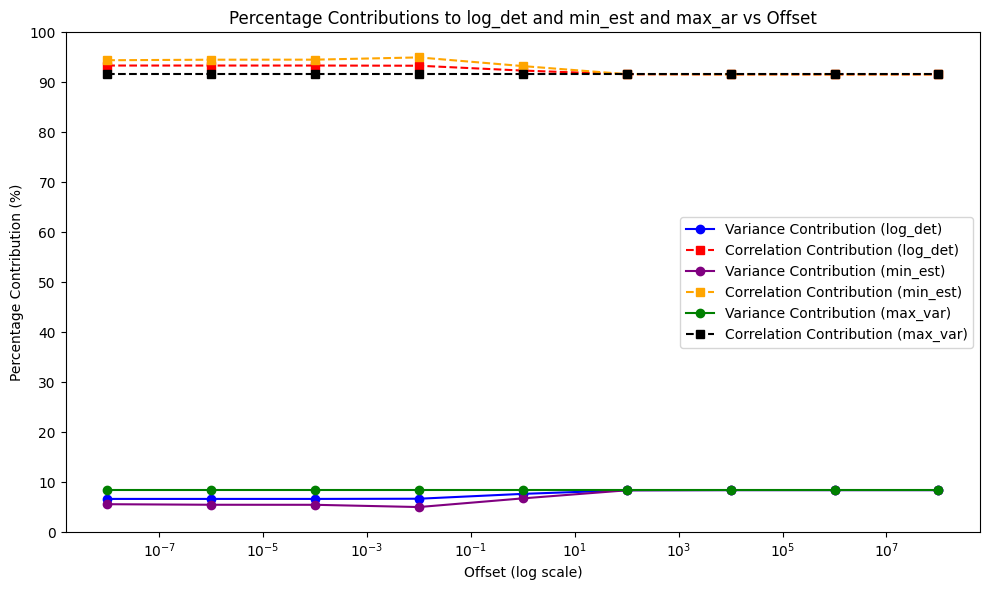

In [42]:
offsets_array = np.array(offsets)

plt.figure(figsize=(10, 6))

# Plot contributions for log_det
plt.plot(offsets_array, perc_var_log_dets, label='Variance Contribution (log_det)', marker='o', linestyle='-', color='blue')
plt.plot(offsets_array, perc_corr_log_dets, label='Correlation Contribution (log_det)', marker='s', linestyle='--', color='red')
plt.plot(offsets_array, perc_var_min_ests, label='Variance Contribution (min_est)', marker='o', linestyle='-', color='purple')
plt.plot(offsets_array, perc_corr_min_ests, label='Correlation Contribution (min_est)', marker='s', linestyle='--', color='orange')
plt.plot(offsets_array, perc_var_max_vars, label='Variance Contribution (max_var)', marker='o', linestyle='-', color='green')
plt.plot(offsets_array, perc_corr_max_vars, label='Correlation Contribution (max_var)', marker='s', linestyle='--', color='black')


plt.xscale('log')
plt.xlabel('Offset (log scale)')
plt.ylabel('Percentage Contribution (%)')
plt.title('Percentage Contributions to log_det and min_est and max_ar vs Offset')

plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=10))
plt.ylim(0, 100)

plt.legend()
plt.tight_layout()
plt.show()
